In [1]:
import numpy as np
import pandas as pd

In [44]:
biomarkers = ['KLRD1','FCGR1A','NKG7','CXCL11','CXCL9','PRF1','MSR1',
'EOMES','APOL3','SAMD3','IRF8','GBP1','HLA-F','RUNX3','STAT1','TRAF5','CSF2RA',
'CCL5','HCP5','ENTPD1']

cell_cycle = ['ANLN','ASPM','BUB1','BUB1B','CCNA2','CCNB1','CDKN3','CENPA','CENPF','CEP55','DLGAP5','DTL','EZH2','KIAA0101','KIF11','KIF20A','MKI67','NUSAP1','RRM2','TOP2A','TPX2','TTK','TYMS','UBE2C']

In [45]:
degs_liver = pd.read_excel("./data/degs_result_liver.xlsx")
degs_liver.index = degs_liver['Gene']
degs_lung = pd.read_excel("./data/degs_result_lung.xlsx")
degs_lung.index = degs_lung['Gene']
degs_heart = pd.read_excel("./data/degs_result_heart.xlsx")
degs_heart.index = degs_heart['Gene']
degs_kidney = pd.read_excel("./data/degs_result_kidney.xlsx")
degs_kidney.index  = degs_kidney['Gene']

In [46]:
# List of all your result dataframes
deg_tables = {
    'liver': degs_liver,
    'lung': degs_lung,
    'heart': degs_heart,
    'kidney': degs_kidney
}

In [47]:
biomarker_subsets = {}
cell_cycle_subsets = {}

for organ, df in deg_tables.items():    
    existing_biomarkers = df.index.intersection(biomarkers)
    biomarker_subsets[organ] = df.loc[existing_biomarkers]
    
    existing_cc = df.index.intersection(cell_cycle)
    cell_cycle_subsets[organ] = df.loc[existing_cc]
    
    print(f"{organ.capitalize()}: Found {len(existing_biomarkers)} biomarkers and {len(existing_cc)} cell cycle genes.")


Liver: Found 20 biomarkers and 24 cell cycle genes.
Lung: Found 20 biomarkers and 24 cell cycle genes.
Heart: Found 20 biomarkers and 24 cell cycle genes.
Kidney: Found 20 biomarkers and 24 cell cycle genes.


In [48]:
organs = ['liver', 'kidney', 'heart', 'lung']

biomarker_list = []
for organ in organs:
    df = biomarker_subsets[organ][['logFC', 'adj.P.Val']].copy()
    df.columns = [f'{organ}.logFC', f'{organ}.adj.P.Val']
    biomarker_list.append(df)
combined_biomarkers = pd.concat(biomarker_list, axis=1)
combined_biomarkers.insert(0, 'Gene', combined_biomarkers.index)

cc_list = []
for organ in organs:
    df = cell_cycle_subsets[organ][['logFC', 'adj.P.Val']].copy()
    df.columns = [f'{organ}.logFC', f'{organ}.adj.P.Val']
    cc_list.append(df)
combined_cell_cycle = pd.concat(cc_list, axis=1)
combined_cell_cycle.insert(0, 'Gene', combined_cell_cycle.index)

In [52]:
def get_status(logFC, adj_P):
    if adj_P >= 0.05: return "non-significant"
    return "upregulated" if logFC > 0 else "downregulated"

for organ in organs:
    lfc, pval, stat = f'{organ}.logFC', f'{organ}.adj.P.Val', f'{organ}.status'
    
    combined_biomarkers[stat] = combined_biomarkers.apply(lambda x: get_status(x[lfc], x[pval]), axis=1)
    combined_cell_cycle[stat] = combined_cell_cycle.apply(lambda x: get_status(x[lfc], x[pval]), axis=1)

In [53]:
reordered_columns = [
    'Gene',
    'liver.logFC', 'liver.adj.P.Val', 'liver.status',
    'kidney.logFC', 'kidney.adj.P.Val', 'kidney.status',
    'heart.logFC', 'heart.adj.P.Val', 'heart.status',
    'lung.logFC', 'lung.adj.P.Val', 'lung.status'
]

combined_biomarkers = combined_biomarkers[reordered_columns]
combined_cell_cycle = combined_cell_cycle[reordered_columns]

combined_biomarkers.to_excel("./data/biomarker_final_report.xlsx", index=False)
combined_cell_cycle.to_excel("./data/cell_cycle_final_report.xlsx", index=False)

#### Plot

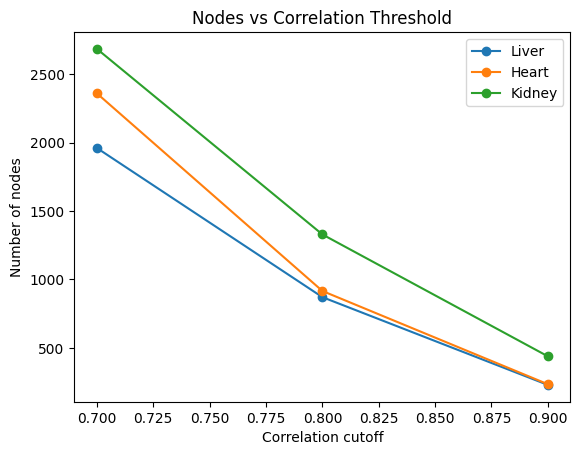

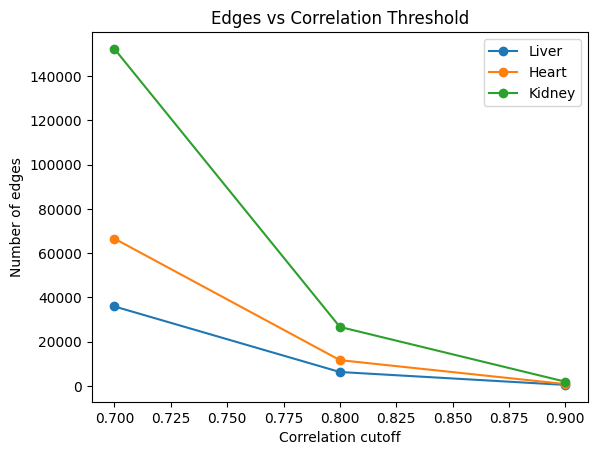

In [3]:
import os
import matplotlib.pyplot as plt

organs = ["liver", "heart", "kidney"]
correlation_cutoffs = [0.7, 0.8, 0.9]

nodes_liver = [1960, 871, 230]
nodes_kidney = [2684, 1329, 439]
nodes_heart = [2359, 916, 235]

edges_liver = [35897, 6282, 449]
edges_kidney = [152215, 26638, 1903]
edges_heart = [66521, 11642, 832]

# ensure figures folder exists
os.makedirs("./figures", exist_ok=True)

# -------- Nodes plot --------
plt.figure()
plt.plot(correlation_cutoffs, nodes_liver, marker='o', label="Liver")
plt.plot(correlation_cutoffs, nodes_heart, marker='o', label="Heart")
plt.plot(correlation_cutoffs, nodes_kidney, marker='o', label="Kidney")

plt.xlabel("Correlation cutoff")
plt.ylabel("Number of nodes")
plt.title("Nodes vs Correlation Threshold")
plt.legend()

plt.savefig("./figures/nodes_vs_correlation_threshold.png", dpi=600, bbox_inches="tight")
plt.show()


# -------- Edges plot --------
plt.figure()
plt.plot(correlation_cutoffs, edges_liver, marker='o', label="Liver")
plt.plot(correlation_cutoffs, edges_heart, marker='o', label="Heart")
plt.plot(correlation_cutoffs, edges_kidney, marker='o', label="Kidney")

plt.xlabel("Correlation cutoff")
plt.ylabel("Number of edges")
plt.title("Edges vs Correlation Threshold")
plt.legend()

plt.savefig("./figures/edges_vs_correlation_threshold.png", dpi=600, bbox_inches="tight")
plt.show()

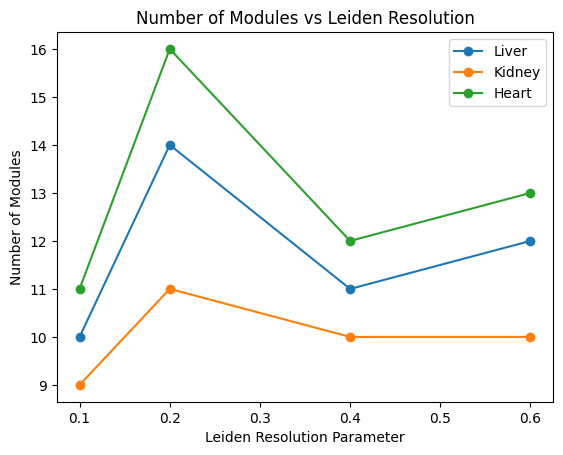

In [4]:
lieden_clustering_resolutions = [0.1, 0.2, 0.4, 0.6]

no_liver_modules = [10, 14, 11, 12]
no_kidney_modules = [9, 11, 10, 10]
no_heart_modules = [11, 16, 12, 13]

# ensure figures directory exists
os.makedirs("./figures", exist_ok=True)

plt.figure()

plt.plot(lieden_clustering_resolutions, no_liver_modules, marker='o', label="Liver")
plt.plot(lieden_clustering_resolutions, no_kidney_modules, marker='o', label="Kidney")
plt.plot(lieden_clustering_resolutions, no_heart_modules, marker='o', label="Heart")

plt.xlabel("Leiden Resolution Parameter")
plt.ylabel("Number of Modules")
plt.title("Number of Modules vs Leiden Resolution")
plt.legend()

plt.savefig("./figures/leiden_resolution_vs_modules.png", dpi=600, bbox_inches="tight")

plt.show()